<a href="https://colab.research.google.com/github/Artemfff777/school_project_ML/blob/main/project_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Все библиотеки загружены
   TensorFlow версия: 2.19.0
   GPU доступен: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
ЗАГРУЗКА ДАННЫХ

 Загрузка MNIST...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   Обучающая выборка: (60000, 28, 28)
   Тестовая выборка: (10000, 28, 28)

 Загрузка CIFAR-10...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
   Обучающая выборка: (50000, 32, 32, 3)
   Тестовая выборка: (10000, 32, 32, 3)

 Подвыборка CIFAR-10 для обучения: 10000 изображений
ИЗВЛЕЧЕНИЕ HOG-ПРИЗНАКОВ

  Извлечение HOG для MNIST...
   Обработано 2000 из 60000 изображений
   Обработано 4000 из 60000 изображений
   Обработано 6000 из 60000 изображений
   Обработано 8000 из 60000 изображений
   Обработано 10000 из 60000 изображений
   Обработано 12000 из 60000 изображений
   Обработано 14000 из 60000 изображений
   Обработано 16000 из 60000 изображений
   Обработано 18000 из 60000 изображений
   Обработано 20000 из 60000 изображений
   Обработано 22000 из 6000

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Точность: 0.9920
   Время обучения: 22.70 сек

 2. CNN на CIFAR-10
   Точность: 0.6292
   Время обучения: 46.24 сек
СВОДНАЯ ТАБЛИЦА ВСЕХ МЕТРИК

--------------------------------------------------------------------------------
 ДАТАСЕТ MNIST
--------------------------------------------------------------------------------
Модель                   Accuracy     Precision    Recall       F1-score     Время обучения (сек)
--------------------------------------------------------------------------------
SVM + HOG                0.9575       0.9575       0.9575       0.9574       21.67          
Random Forest + HOG      0.9528       0.9528       0.9528       0.9527       67.46          
CNN                      0.9920       0.9920       0.9920       0.9920       22.70          

--------------------------------------------------------------------------------
 ДАТАСЕТ CIFAR-10
--------------------------------------------------------------------------------
Модель                   Accuracy   

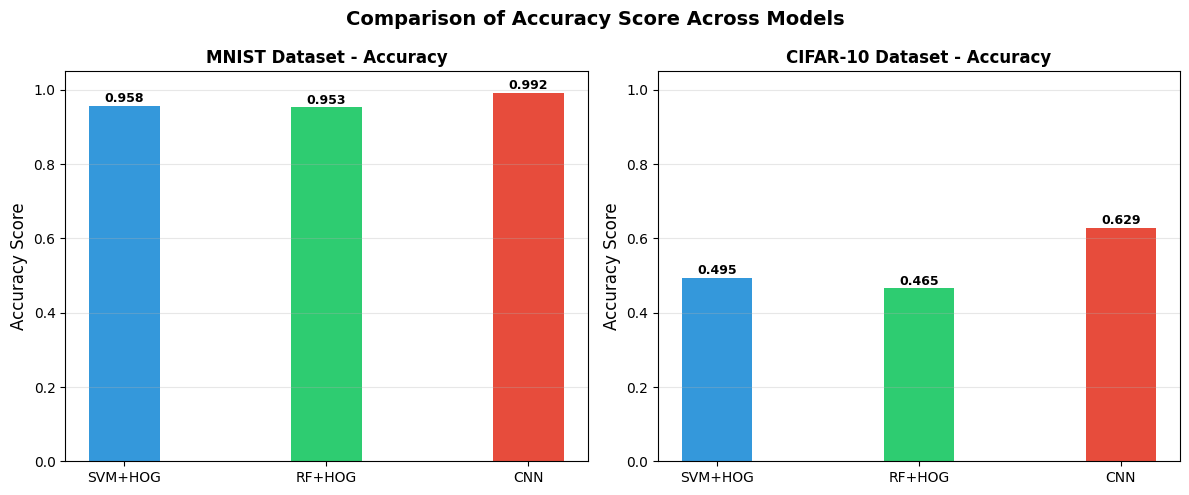


 Диаграмма 2: Precision


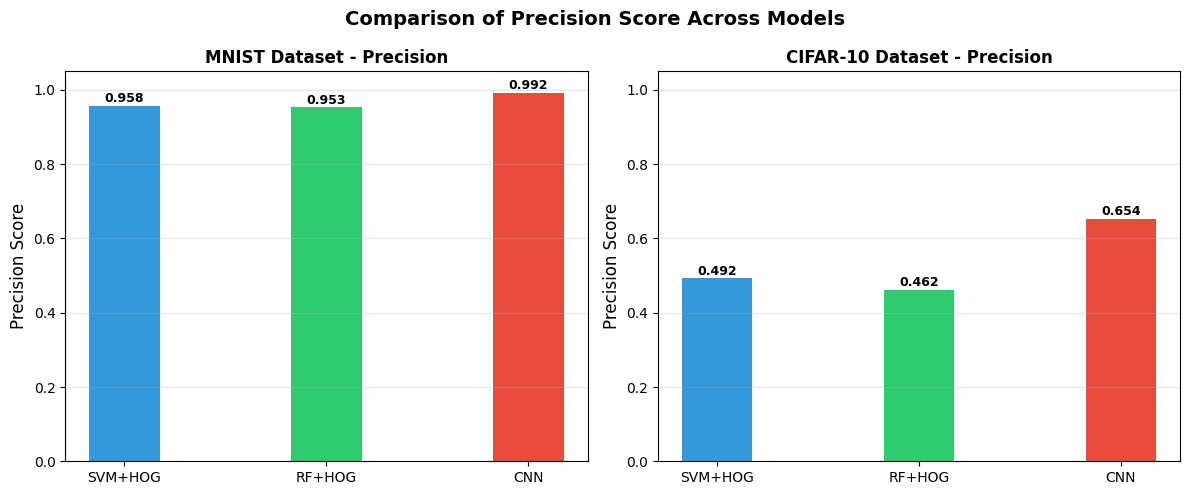


 Диаграмма 3: Recall


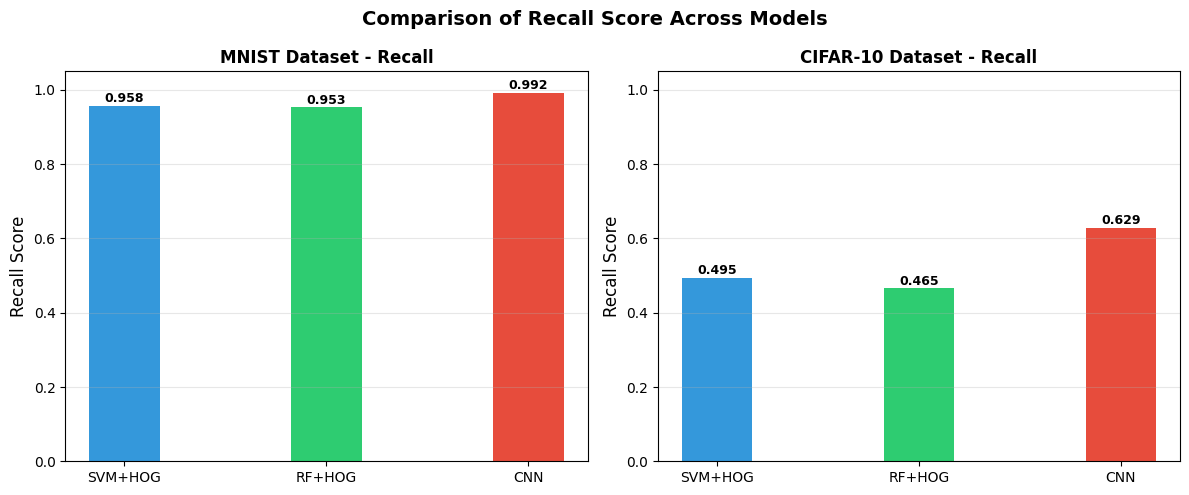


 Диаграмма 4: F1-Score


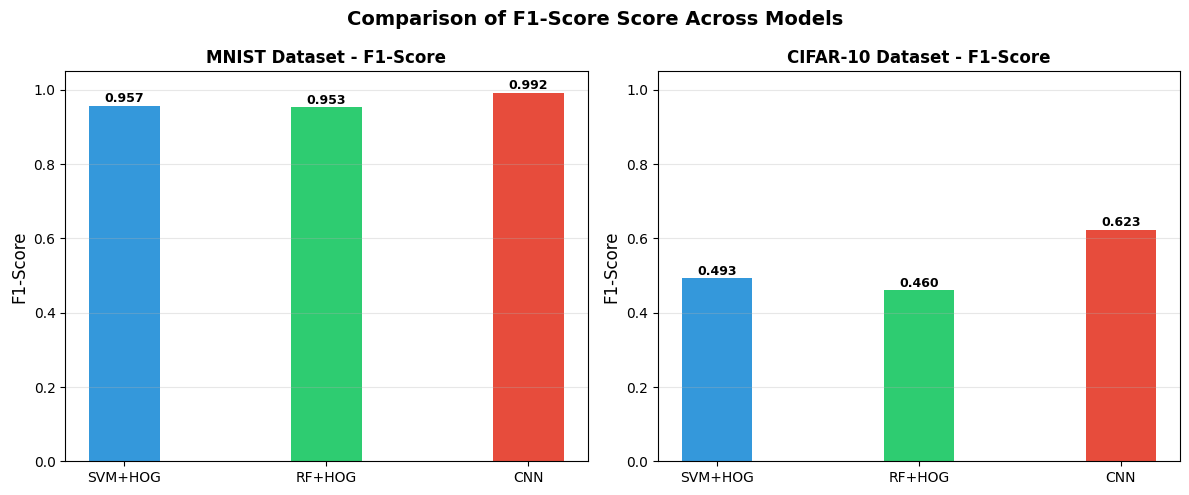


 Диаграмма 5: Training Time


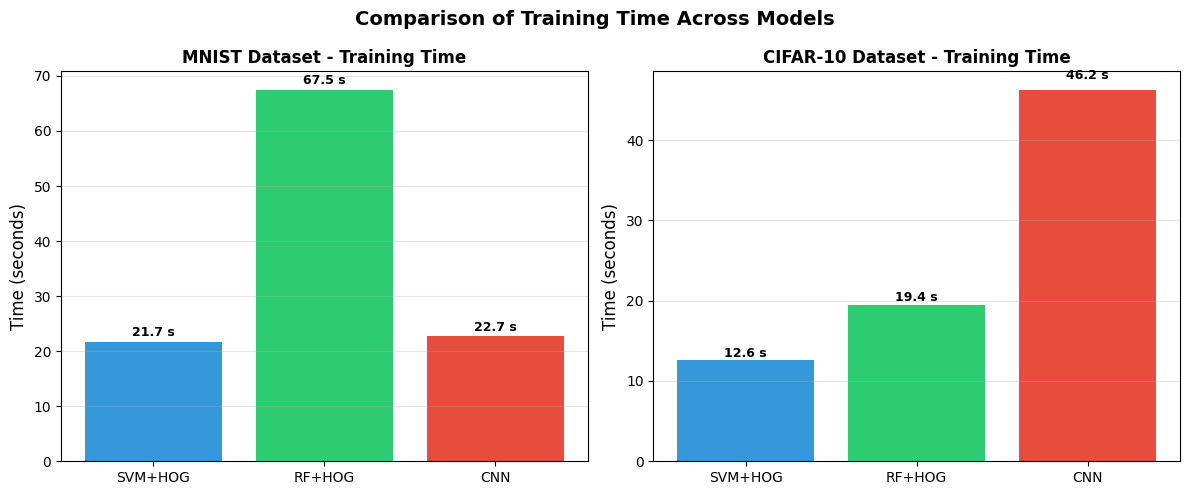

 ВСЕ ДИАГРАММЫ СОХРАНЕНЫ:
   - metric_accuracy.png
   - metric_precision.png
   - metric_recall.png
   - metric_f1score.png
   - metric_training_time.png

СРАВНЕНИЕ ВРЕМЕНИ ПРЕДСКАЗАНИЯ
⏱️  Выполняется замер времени предсказания...
   Обработано 20 из 100 изображений
   Обработано 40 из 100 изображений
   Обработано 60 из 100 изображений
   Обработано 80 из 100 изображений
   Обработано 100 из 100 изображений

--------------------------------------------------
РЕЗУЛЬТАТЫ (в миллисекундах):
--------------------------------------------------
SVM + HOG:        2.62 ± 0.25 мс
Random Forest:    23.64 ± 2.50 мс
CNN:              82.76 ± 78.76 мс
--------------------------------------------------


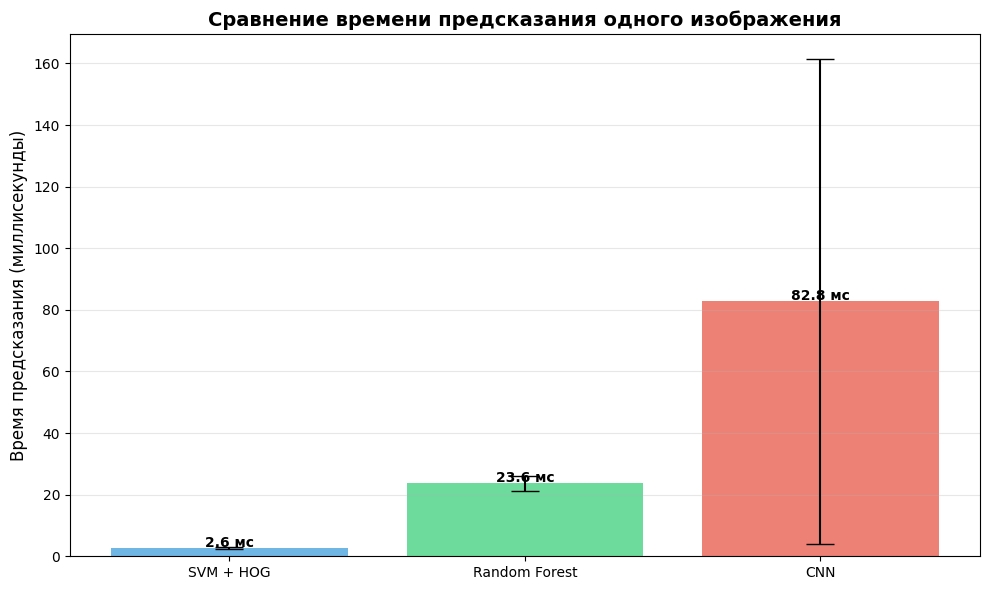


 График сохранён: prediction_time_comparison.png


In [1]:
# ============================================================
# БЛОК 1: ИМПОРТ БИБЛИОТЕК
# ============================================================

import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras для нейронных сетей
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Scikit-learn для классических алгоритмов и метрик
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

# Обработка изображений
from skimage.feature import hog
from skimage.color import rgb2gray

# Датасеты
from tensorflow.keras.datasets import mnist, cifar10

# Фиксация seed для воспроизводимости
np.random.seed(42)
tf.random.set_seed(42)

print("Все библиотеки загружены")
print(f"   TensorFlow версия: {tf.__version__}")
print(f"   GPU доступен: {tf.config.list_physical_devices('GPU')}")

# ============================================================
# БЛОК 2: ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================================

print("ЗАГРУЗКА ДАННЫХ")

# Загрузка MNIST
print("\n Загрузка MNIST...")
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
print(f"   Обучающая выборка: {x_train_mnist.shape}")
print(f"   Тестовая выборка: {x_test_mnist.shape}")

# Загрузка CIFAR-10
print("\n Загрузка CIFAR-10...")
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()
print(f"   Обучающая выборка: {x_train_cifar.shape}")
print(f"   Тестовая выборка: {x_test_cifar.shape}")

# Названия классов
mnist_classes = [str(i) for i in range(10)]
cifar_classes = ['самолет', 'автомобиль', 'птица', 'кошка', 'олень',
                 'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

# Нормализация (приводим пиксели к диапазону [0,1])
x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0
x_train_cifar = x_train_cifar.astype('float32') / 255.0
x_test_cifar = x_test_cifar.astype('float32') / 255.0

# Преобразование меток в одномерные массивы (для sklearn)
y_train_mnist_flat = y_train_mnist.ravel()
y_test_mnist_flat = y_test_mnist.ravel()
y_train_cifar_flat = y_train_cifar.ravel()
y_test_cifar_flat = y_test_cifar.ravel()

# Для ускорения берём подвыборку из CIFAR-10 (10 000 изображений)
x_train_cifar_small, _, y_train_cifar_small, _ = train_test_split(
    x_train_cifar, y_train_cifar_flat,
    train_size=10000,
    random_state=42,
    stratify=y_train_cifar_flat
)
print(f"\n Подвыборка CIFAR-10 для обучения: {x_train_cifar_small.shape[0]} изображений")

# ============================================================
# БЛОК 3: ИЗВЛЕЧЕНИЕ HOG-ПРИЗНАКОВ
# ============================================================

print("ИЗВЛЕЧЕНИЕ HOG-ПРИЗНАКОВ")

def extract_hog_features(images, verbose=True):
    """
    Извлекает HOG-признаки из набора изображений.

    Параметры:
    - images: массив изображений
    - verbose: выводить прогресс

    Возвращает:
    - массив HOG-признаков
    """
    hog_features = []
    n_images = len(images)

    for i, img in enumerate(images):
        # Если изображение цветное (3 канала), преобразуем в черно-белое
        if len(img.shape) == 3 and img.shape[-1] == 3:
            gray = rgb2gray(img)
        else:
            gray = img

        # Извлечение HOG-дескриптора
        fd = hog(gray,
                orientations=9,           # 9 направлений градиента
                pixels_per_cell=(8, 8),   # ячейка 8x8 пикселей
                cells_per_block=(2, 2),   # блок 2x2 ячейки
                block_norm='L2-Hys')

        hog_features.append(fd)

        if verbose and (i + 1) % 2000 == 0:
            print(f"   Обработано {i+1} из {n_images} изображений")

    return np.array(hog_features)

# Извлечение для MNIST
print("\n  Извлечение HOG для MNIST...")
start = time.time()
X_train_hog_mnist = extract_hog_features(x_train_mnist)
X_test_hog_mnist = extract_hog_features(x_test_mnist)
print(f"   Размерность признаков: {X_train_hog_mnist.shape[1]}")
print(f"   Время: {time.time() - start:.2f} сек")

# Извлечение для CIFAR-10
print("\n  Извлечение HOG для CIFAR-10...")
start = time.time()
X_train_hog_cifar = extract_hog_features(x_train_cifar_small)
X_test_hog_cifar = extract_hog_features(x_test_cifar)
print(f"   Размерность признаков: {X_test_hog_cifar.shape[1]}")
print(f"   Время: {time.time() - start:.2f} сек")

# ============================================================
# БЛОК 4: КЛАССИЧЕСКИЕ АЛГОРИТМЫ (SVM и Random Forest)
# ============================================================

print("ОБУЧЕНИЕ КЛАССИЧЕСКИХ МОДЕЛЕЙ")

# SVM на MNIST
print("\n 1. SVM на MNIST")
start = time.time()
svm_mnist = SVC(kernel='linear', C=1.0, random_state=42)
svm_mnist.fit(X_train_hog_mnist, y_train_mnist_flat)
svm_mnist_time = time.time() - start

y_pred_svm_mnist = svm_mnist.predict(X_test_hog_mnist)
svm_mnist_acc = accuracy_score(y_test_mnist_flat, y_pred_svm_mnist)
print(f"   Точность: {svm_mnist_acc:.4f}")
print(f"   Время обучения: {svm_mnist_time:.2f} сек")

# Random Forest на MNIST
print("\n 2. Random Forest на MNIST")
start = time.time()
rf_mnist = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mnist.fit(X_train_hog_mnist, y_train_mnist_flat)
rf_mnist_time = time.time() - start

y_pred_rf_mnist = rf_mnist.predict(X_test_hog_mnist)
rf_mnist_acc = accuracy_score(y_test_mnist_flat, y_pred_rf_mnist)
print(f"   Точность: {rf_mnist_acc:.4f}")
print(f"   Время обучения: {rf_mnist_time:.2f} сек")

# SVM на CIFAR-10
print("\n 3. SVM на CIFAR-10")
start = time.time()
svm_cifar = SVC(kernel='linear', C=1.0, random_state=42)
svm_cifar.fit(X_train_hog_cifar, y_train_cifar_small)
svm_cifar_time = time.time() - start

y_pred_svm_cifar = svm_cifar.predict(X_test_hog_cifar)
svm_cifar_acc = accuracy_score(y_test_cifar_flat, y_pred_svm_cifar)
print(f"   Точность: {svm_cifar_acc:.4f}")
print(f"   Время обучения: {svm_cifar_time:.2f} сек")

# Random Forest на CIFAR-10
print("\n 4. Random Forest на CIFAR-10")
start = time.time()
rf_cifar = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_cifar.fit(X_train_hog_cifar, y_train_cifar_small)
rf_cifar_time = time.time() - start

y_pred_rf_cifar = rf_cifar.predict(X_test_hog_cifar)
rf_cifar_acc = accuracy_score(y_test_cifar_flat, y_pred_rf_cifar)
print(f"   Точность: {rf_cifar_acc:.4f}")
print(f"   Время обучения: {rf_cifar_time:.2f} сек")

# ============================================================
# БЛОК 5: СВЕРТОЧНАЯ НЕЙРОННАЯ СЕТЬ (CNN)
# ============================================================

print("СОЗДАНИЕ И ОБУЧЕНИЕ CNN")

def create_cnn_mnist():
    """Упрощённая CNN для MNIST"""
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

def create_cnn_cifar():
    """Более глубокая CNN для CIFAR-10"""
    model = keras.Sequential([
        # Блок 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Блок 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Блок 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Полносвязные слои
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

# CNN на MNIST
print("\n 1. CNN на MNIST")

cnn_mnist = create_cnn_mnist()
cnn_mnist.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Подготовка данных (добавляем канал)
x_train_mnist_cnn = x_train_mnist.reshape(-1, 28, 28, 1)
x_test_mnist_cnn = x_test_mnist.reshape(-1, 28, 28, 1)

start = time.time()
history_mnist = cnn_mnist.fit(
    x_train_mnist_cnn, y_train_mnist_flat,
    epochs=10, batch_size=128,
    validation_split=0.2,
    verbose=0
)
cnn_mnist_time = time.time() - start

cnn_mnist_acc = cnn_mnist.evaluate(x_test_mnist_cnn, y_test_mnist_flat, verbose=0)[1]
y_pred_cnn_mnist = np.argmax(cnn_mnist.predict(x_test_mnist_cnn, verbose=0), axis=1)
print(f"   Точность: {cnn_mnist_acc:.4f}")
print(f"   Время обучения: {cnn_mnist_time:.2f} сек")

# CNN на CIFAR-10
print("\n 2. CNN на CIFAR-10")

cnn_cifar = create_cnn_cifar()
cnn_cifar.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

start = time.time()
history_cifar = cnn_cifar.fit(
    x_train_cifar_small, y_train_cifar_small,
    epochs=15, batch_size=64,
    validation_data=(x_test_cifar, y_test_cifar_flat),
    verbose=0
)
cnn_cifar_time = time.time() - start

cnn_cifar_acc = cnn_cifar.evaluate(x_test_cifar, y_test_cifar_flat, verbose=0)[1]
y_pred_cnn_cifar = np.argmax(cnn_cifar.predict(x_test_cifar, verbose=0), axis=1)
print(f"   Точность: {cnn_cifar_acc:.4f}")
print(f"   Время обучения: {cnn_cifar_time:.2f} сек")

# ============================================================
# БЛОК 6: СВОДНАЯ ТАБЛИЦА ВСЕХ МЕТРИК
# ============================================================

print("СВОДНАЯ ТАБЛИЦА ВСЕХ МЕТРИК")

def print_metrics_table(model_name, y_true, y_pred, train_time):
    """Выводит все метрики для модели"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"{model_name:<24} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {train_time:<15.2f}")
    return acc, prec, rec, f1

# MNIST
print("\n" + "-"*80)
print(" ДАТАСЕТ MNIST")
print("-"*80)
print(f"{'Модель':<24} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-score':<12} {'Время обучения (сек)':<15}")
print("-"*80)

print_metrics_table("SVM + HOG", y_test_mnist_flat, y_pred_svm_mnist, svm_mnist_time)
print_metrics_table("Random Forest + HOG", y_test_mnist_flat, y_pred_rf_mnist, rf_mnist_time)
print_metrics_table("CNN", y_test_mnist_flat, y_pred_cnn_mnist, cnn_mnist_time)

# CIFAR-10
print("\n" + "-"*80)
print(" ДАТАСЕТ CIFAR-10")
print("-"*80)
print(f"{'Модель':<24} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-score':<12} {'Время обучения (сек)':<15}")
print("-"*80)

print_metrics_table("SVM + HOG", y_test_cifar_flat, y_pred_svm_cifar, svm_cifar_time)
print_metrics_table("Random Forest + HOG", y_test_cifar_flat, y_pred_rf_cifar, rf_cifar_time)
print_metrics_table("CNN", y_test_cifar_flat, y_pred_cnn_cifar, cnn_cifar_time)

# ============================================================
# БЛОК 7: МАТРИЦЫ ОШИБОК ДЛЯ ВСЕХ МОДЕЛЕЙ
# ============================================================

print("ПОСТРОЕНИЕ МАТРИЦ ОШИБОК")

def plot_confusion_matrix(y_true, y_pred, classes, title, filename, cmap='Blues'):
    """Строит и сохраняет матрицу ошибок"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Предсказанный класс', fontsize=12)
    plt.ylabel('Истинный класс', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.close()

# MNIST
print("\n Матрицы ошибок на MNIST...")
plot_confusion_matrix(y_test_mnist_flat, y_pred_svm_mnist, mnist_classes,
                      'SVM + HOG на MNIST', 'cm_svm_mnist.png', 'Blues')
plot_confusion_matrix(y_test_mnist_flat, y_pred_rf_mnist, mnist_classes,
                      'Random Forest + HOG на MNIST', 'cm_rf_mnist.png', 'Greens')
plot_confusion_matrix(y_test_mnist_flat, y_pred_cnn_mnist, mnist_classes,
                      'CNN на MNIST', 'cm_cnn_mnist.png', 'Reds')

# CIFAR-10
print("\n Матрицы ошибок на CIFAR-10...")
plot_confusion_matrix(y_test_cifar_flat, y_pred_svm_cifar, cifar_classes,
                      'SVM + HOG на CIFAR-10', 'cm_svm_cifar.png', 'Blues')
plot_confusion_matrix(y_test_cifar_flat, y_pred_rf_cifar, cifar_classes,
                      'Random Forest + HOG на CIFAR-10', 'cm_rf_cifar.png', 'Greens')
plot_confusion_matrix(y_test_cifar_flat, y_pred_cnn_cifar, cifar_classes,
                      'CNN на CIFAR-10', 'cm_cnn_cifar.png', 'Reds')

print(" Все матрицы ошибок сохранены")

# ============================================================
# БЛОК 8: ДИАГРАММЫ ДЛЯ КАЖДОЙ МЕТРИКИ (НА АНГЛИЙСКОМ)
# ============================================================

print("ПОСТРОЕНИЕ ДИАГРАММ ПО МЕТРИКАМ")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ВЫЧИСЛЯЕМ ВСЕ МЕТРИКИ ДЛЯ ВСЕХ МОДЕЛЕЙ

# ---MNIST---
# SVM
acc_svm_mnist = accuracy_score(y_test_mnist_flat, y_pred_svm_mnist)
prec_svm_mnist = precision_score(y_test_mnist_flat, y_pred_svm_mnist, average='weighted')
rec_svm_mnist = recall_score(y_test_mnist_flat, y_pred_svm_mnist, average='weighted')
f1_svm_mnist = f1_score(y_test_mnist_flat, y_pred_svm_mnist, average='weighted')

# Random Forest
acc_rf_mnist = accuracy_score(y_test_mnist_flat, y_pred_rf_mnist)
prec_rf_mnist = precision_score(y_test_mnist_flat, y_pred_rf_mnist, average='weighted')
rec_rf_mnist = recall_score(y_test_mnist_flat, y_pred_rf_mnist, average='weighted')
f1_rf_mnist = f1_score(y_test_mnist_flat, y_pred_rf_mnist, average='weighted')

# CNN
acc_cnn_mnist = accuracy_score(y_test_mnist_flat, y_pred_cnn_mnist)
prec_cnn_mnist = precision_score(y_test_mnist_flat, y_pred_cnn_mnist, average='weighted')
rec_cnn_mnist = recall_score(y_test_mnist_flat, y_pred_cnn_mnist, average='weighted')
f1_cnn_mnist = f1_score(y_test_mnist_flat, y_pred_cnn_mnist, average='weighted')

# ---CIFAR-10---
# SVM
acc_svm_cifar = accuracy_score(y_test_cifar_flat, y_pred_svm_cifar)
prec_svm_cifar = precision_score(y_test_cifar_flat, y_pred_svm_cifar, average='weighted')
rec_svm_cifar = recall_score(y_test_cifar_flat, y_pred_svm_cifar, average='weighted')
f1_svm_cifar = f1_score(y_test_cifar_flat, y_pred_svm_cifar, average='weighted')

# Random Forest
acc_rf_cifar = accuracy_score(y_test_cifar_flat, y_pred_rf_cifar)
prec_rf_cifar = precision_score(y_test_cifar_flat, y_pred_rf_cifar, average='weighted')
rec_rf_cifar = recall_score(y_test_cifar_flat, y_pred_rf_cifar, average='weighted')
f1_rf_cifar = f1_score(y_test_cifar_flat, y_pred_rf_cifar, average='weighted')

# CNN
acc_cnn_cifar = accuracy_score(y_test_cifar_flat, y_pred_cnn_cifar)
prec_cnn_cifar = precision_score(y_test_cifar_flat, y_pred_cnn_cifar, average='weighted')
rec_cnn_cifar = recall_score(y_test_cifar_flat, y_pred_cnn_cifar, average='weighted')
f1_cnn_cifar = f1_score(y_test_cifar_flat, y_pred_cnn_cifar, average='weighted')

# ФУНКЦИЯ ДЛЯ ПОСТРОЕНИЯ ДИАГРАММ

def plot_metric(metric_name, metric_values_mnist, metric_values_cifar, y_label, filename):
    """
    Строит диаграмму для одной метрики на двух датасетах
    """
    models = ['SVM+HOG', 'RF+HOG', 'CNN']
    x = np.arange(len(models))
    width = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # MNIST
    bars1 = ax1.bar(models, metric_values_mnist, width, color=['#3498db', '#2ecc71', '#e74c3c'])
    ax1.set_ylabel(y_label, fontsize=12)
    ax1.set_title(f'MNIST Dataset - {metric_name}', fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 1.05)
    ax1.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбцы
    for bar, val in zip(bars1, metric_values_mnist):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

    # CIFAR-10
    bars2 = ax2.bar(models, metric_values_cifar, width, color=['#3498db', '#2ecc71', '#e74c3c'])
    ax2.set_ylabel(y_label, fontsize=12)
    ax2.set_title(f'CIFAR-10 Dataset - {metric_name}', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 1.05)
    ax2.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars2, metric_values_cifar):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

    plt.suptitle(f'Comparison of {metric_name} Score Across Models', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

# ДИАГРАММА 1: ACCURACY

print("\n Диаграмма 1: Accuracy")

mnist_acc = [acc_svm_mnist, acc_rf_mnist, acc_cnn_mnist]
cifar_acc = [acc_svm_cifar, acc_rf_cifar, acc_cnn_cifar]

plot_metric('Accuracy', mnist_acc, cifar_acc, 'Accuracy Score', 'metric_accuracy.png')

# ДИАГРАММА 2: PRECISION

print("\n Диаграмма 2: Precision")

mnist_prec = [prec_svm_mnist, prec_rf_mnist, prec_cnn_mnist]
cifar_prec = [prec_svm_cifar, prec_rf_cifar, prec_cnn_cifar]

plot_metric('Precision', mnist_prec, cifar_prec, 'Precision Score', 'metric_precision.png')

# ДИАГРАММА 3: RECALL

print("\n Диаграмма 3: Recall")

mnist_rec = [rec_svm_mnist, rec_rf_mnist, rec_cnn_mnist]
cifar_rec = [rec_svm_cifar, rec_rf_cifar, rec_cnn_cifar]

plot_metric('Recall', mnist_rec, cifar_rec, 'Recall Score', 'metric_recall.png')

# ДИАГРАММА 4: F1-SCORE

print("\n Диаграмма 4: F1-Score")

mnist_f1 = [f1_svm_mnist, f1_rf_mnist, f1_cnn_mnist]
cifar_f1 = [f1_svm_cifar, f1_rf_cifar, f1_cnn_cifar]

plot_metric('F1-Score', mnist_f1, cifar_f1, 'F1-Score', 'metric_f1score.png')

# ДИАГРАММА 5: ВРЕМЯ ОБУЧЕНИЯ (ОТДЕЛЬНО, ТАК КАК ДРУГАЯ ШКАЛА)

print("\n Диаграмма 5: Training Time")

plt.figure(figsize=(12, 5))

models = ['SVM+HOG', 'RF+HOG', 'CNN']
mnist_times = [svm_mnist_time, rf_mnist_time, cnn_mnist_time]
cifar_times = [svm_cifar_time, rf_cifar_time, cnn_cifar_time]

# MNIST
plt.subplot(1, 2, 1)
bars1 = plt.bar(models, mnist_times, color=['#3498db', '#2ecc71', '#e74c3c'])
plt.ylabel('Time (seconds)', fontsize=12)
plt.title('MNIST Dataset - Training Time', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar, t in zip(bars1, mnist_times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{t:.1f} s', ha='center', fontsize=9, fontweight='bold')

# CIFAR-10
plt.subplot(1, 2, 2)
bars2 = plt.bar(models, cifar_times, color=['#3498db', '#2ecc71', '#e74c3c'])
plt.ylabel('Time (seconds)', fontsize=12)
plt.title('CIFAR-10 Dataset - Training Time', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar, t in zip(bars2, cifar_times):
    # Для CNN делаем отступ побольше
    y_offset = t * 0.03 if t < 1000 else t * 0.05
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
             f'{t:.1f} s', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparison of Training Time Across Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metric_training_time.png', dpi=150)
plt.show()

print(" ВСЕ ДИАГРАММЫ СОХРАНЕНЫ:")
print("   - metric_accuracy.png")
print("   - metric_precision.png")
print("   - metric_recall.png")
print("   - metric_f1score.png")
print("   - metric_training_time.png")

# ============================================================
# БЛОК 9: СРАВНЕНИЕ ВРЕМЕНИ ПРЕДСКАЗАНИЯ
# ============================================================

print("\n" + "="*60)
print("СРАВНЕНИЕ ВРЕМЕНИ ПРЕДСКАЗАНИЯ")
print("="*60)

n_runs = 100
times_svm = []
times_rf = []
times_cnn = []

indices = np.random.choice(len(x_test_cifar), n_runs, replace=False)

print("⏱️  Выполняется замер времени предсказания...")
for idx, i in enumerate(indices):
    # SVM
    start = time.time()
    _ = svm_cifar.predict(X_test_hog_cifar[i:i+1])
    times_svm.append(time.time() - start)

    # Random Forest
    start = time.time()
    _ = rf_cifar.predict(X_test_hog_cifar[i:i+1])
    times_rf.append(time.time() - start)

    # CNN
    start = time.time()
    _ = cnn_cifar.predict(x_test_cifar[i:i+1], verbose=0)
    times_cnn.append(time.time() - start)

    if (idx + 1) % 20 == 0:
        print(f"   Обработано {idx + 1} из {n_runs} изображений")

# Конвертируем в миллисекунды
times_svm_ms = np.array(times_svm) * 1000
times_rf_ms = np.array(times_rf) * 1000
times_cnn_ms = np.array(times_cnn) * 1000

# Вывод статистики
print("\n" + "-"*50)
print("РЕЗУЛЬТАТЫ (в миллисекундах):")
print("-"*50)
print(f"SVM + HOG:        {np.mean(times_svm_ms):.2f} ± {np.std(times_svm_ms):.2f} мс")
print(f"Random Forest:    {np.mean(times_rf_ms):.2f} ± {np.std(times_rf_ms):.2f} мс")
print(f"CNN:              {np.mean(times_cnn_ms):.2f} ± {np.std(times_cnn_ms):.2f} мс")
print("-"*50)

# ГРАФИК: Сравнение времени предсказания

plt.figure(figsize=(10, 6))

models = ['SVM + HOG', 'Random Forest', 'CNN']
means = [np.mean(times_svm_ms), np.mean(times_rf_ms), np.mean(times_cnn_ms)]
stds = [np.std(times_svm_ms), np.std(times_rf_ms), np.std(times_cnn_ms)]

# Строим столбчатую диаграмму с планками погрешностей
bars = plt.bar(models, means, yerr=stds, capsize=10,
               color=['#3498db', '#2ecc71', '#e74c3c'], alpha=0.7)

plt.ylabel('Время предсказания (миллисекунды)', fontsize=12)
plt.title('Сравнение времени предсказания одного изображения', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения над столбцами
for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{mean:.1f} мс', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('prediction_time_comparison.png', dpi=150)
plt.show()

print("\n График сохранён: prediction_time_comparison.png")
